# Fungi Image Classification — TensorFlow/Keras
5 sinif: H1, H2, H3, H5, H6

In [1]:
import os
import shutil
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow versiyonu:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
DEVICE = 'GPU' if gpus else 'CPU'
print('Kullanilan cihaz:', DEVICE)

TensorFlow versiyonu: 2.10.0
Kullanilan cihaz: GPU


## 1. Hyperparameters

In [2]:
IMG_SIZE    = 224
BATCH_SIZE  = 8
EPOCHS      = 50
LR          = 1e-3
PATIENCE    = 5
LR_DECAY    = 0.99
NUM_CLASSES = 5

TRAIN_DIR = 'data/train'
VALID_DIR = 'data/valid'
TEST_DIR  = 'data/test'

## 2. Data Loaders

In [3]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
)
val_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True,
)
valid_gen = val_datagen.flow_from_directory(
    VALID_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False,
)
test_gen = val_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False,
)
print('Class indices:', train_gen.class_indices)

Found 4780 images belonging to 5 classes.
Found 1022 images belonging to 5 classes.
Found 1029 images belonging to 5 classes.
Class indices: {'H1': 0, 'H2': 1, 'H3': 2, 'H5': 3, 'H6': 4}


## 3. CNN Model

In [ ]:
def build_model(num_classes, img_size):
    inputs = keras.Input(shape=(img_size, img_size, 3))

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)


model = build_model(NUM_CLASSES, IMG_SIZE)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     256   

## 4. Callbacks

In [5]:
class LRMultiplicativeDecay(keras.callbacks.Callback):
    def __init__(self, factor=0.99):
        super().__init__()
        self.factor = factor

    def on_epoch_end(self, epoch, logs=None):
        old_lr = float(self.model.optimizer.learning_rate)
        self.model.optimizer.learning_rate.assign(old_lr * self.factor)


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras', monitor='val_loss',
        save_best_only=True, verbose=1,
    ),
    LRMultiplicativeDecay(factor=LR_DECAY),
]

## 5. Compile & Train

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/50
598/598 [==============================] - ETA: 0s - loss: 1.3095 - accuracy: 0.4753
Epoch 1: val_loss improved from inf to 10.94139, saving model to best_model.keras
598/598 [==============================] - 45s 67ms/step - loss: 1.3095 - accuracy: 0.4753 - val_loss: 10.9414 - val_accuracy: 0.2299
Epoch 2/50
598/598 [==============================] - ETA: 0s - loss: 1.1194 - accuracy: 0.5406
Epoch 2: val_loss improved from 10.94139 to 1.24670, saving model to best_model.keras
598/598 [==============================] - 40s 67ms/step - loss: 1.1194 - accuracy: 0.5406 - val_loss: 1.2467 - val_accuracy: 0.4374
Epoch 3/50
598/598 [==============================] - ETA: 0s - loss: 1.0778 - accuracy: 0.5542
Epoch 3: val_loss improved from 1.24670 to 1.11000, saving model to best_model.keras
598/598 [==============================] - 40s 66ms/step - loss: 1.0778 - accuracy: 0.5542 - val_loss: 1.1100 - val_accuracy: 0.5548
Epoch 4/50
598/598 [==============================] - ETA: 

## 6. Training Curves

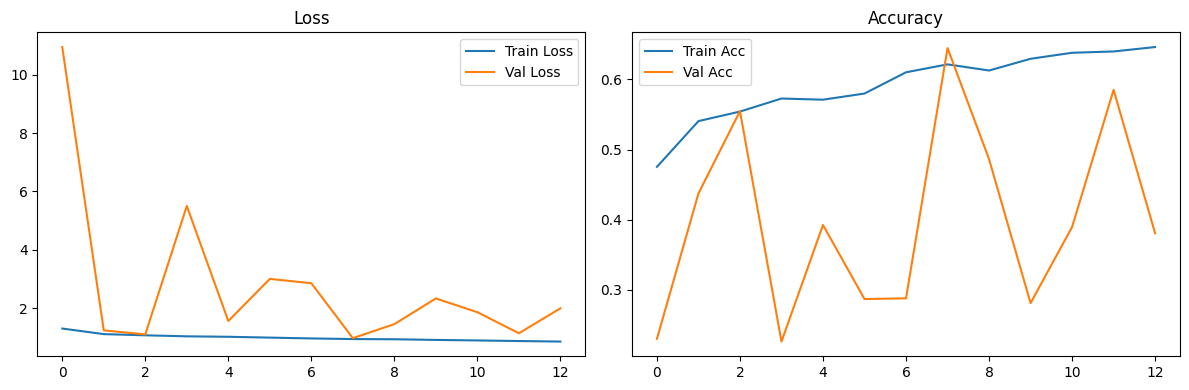

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 7. Evaluate on Test Set

In [8]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}')

129/129 [==============================] - 2s 13ms/step - loss: 0.9911 - accuracy: 0.6288
Test Loss: 0.9911  |  Test Accuracy: 0.6288


## 8. Confusion Matrix

129/129 [==============================] - 1s 10ms/step


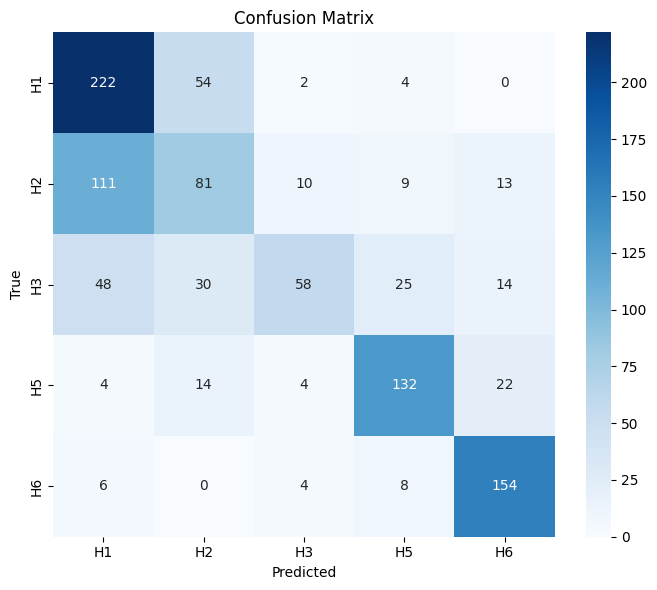

              precision    recall  f1-score   support

          H1       0.57      0.79      0.66       282
          H2       0.45      0.36      0.40       224
          H3       0.74      0.33      0.46       175
          H5       0.74      0.75      0.75       176
          H6       0.76      0.90      0.82       172

    accuracy                           0.63      1029
   macro avg       0.65      0.63      0.62      1029
weighted avg       0.63      0.63      0.61      1029



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))